<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Assignment/ESSA_OB_250307_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#4. 모델 훈련

##4.1 선형 회귀

###4.1.1 정규방정식

In [1]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3*X+np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

theta_best

array([[3.51185344],
       [3.3873906 ]])

In [3]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)

y_predict

array([[ 3.51185344],
       [10.28663464]])

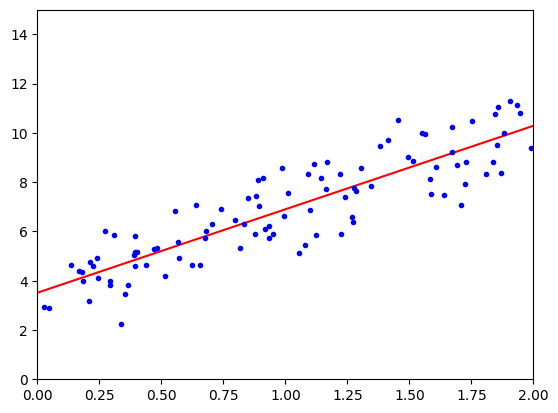

In [4]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])

plt.show()

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(lin_reg.intercept_, lin_reg.coef_)
print(lin_reg.predict(X_new))

[3.51185344] [[3.3873906]]
[[ 3.51185344]
 [10.28663464]]


In [6]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[3.51185344],
       [3.3873906 ]])

In [7]:
np.linalg.pinv(X_b).dot(y)

array([[3.51185344],
       [3.3873906 ]])

###4.1.2 계산 복잡도
정규방정식은 (n+1)*(n+1) 크기의 XtX의 역행렬을 계산함. 역행렬을 계산하는 계산 복잡도는 일반적으로 O(n^2.4)-O(n^3) 사이임
즉, 특성수(n)가 두배로 늘어나면 계산 시간이 약 5~8배 증가하는 것.

사이킷런 LinearRegression에서 사용하는 SVD방법은 약 O(n^2)이므로 특성의 개수가 두 배가 되면 계산 시간이 약 4배가 됨

정규방정식이나 다른 알고리즘으로 학습된 선형 회귀 모델은 예측이 매우 빠름 예측 계산 복잡도는 샘플 수와 특성 수에 선형적임

다음 소개하는 방법은 특성이 매우 많고 훈련 샘플이 너무 많아 메모리에 모두 담을 수 없을 때 적합한 방법들임

##4.2 경사 하강법

###4.2.1 배치 경사 하강법

In [8]:
eta = 0.1
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1)

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

theta

array([[3.51185344],
       [3.3873906 ]])

###4.2.2 확률적 경사 하강법

In [10]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m+i)
    theta = theta - eta * gradients

theta

array([[3.50008443],
       [3.39367591]])

In [12]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter = 1000, tol = 1e-3, penalty = None, eta0 = 0.1)
sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([3.53345882]), array([3.42360112]))

###4.2.3 미니배치 경사 하강법

미니배치 경사 하강법: 미니배치(임의의 작은 샘플 세트)에 대해 그레디언트를 계산

-> 확률 경사 하강법에 비해 행렬 연산에 최적화된 하드웨어(특히 GPU)를 사용하여 성능 향상을 추구

미니배치를 어느정도 크게 하면 파라미터 공간에서 SGD보다 덜 불규칙적으로 움직임
즉 글로벌 옵티멀에 가까이 갈 수 있으나 로컬 옵티멀에서 빠져나오기 어려울 수 있음

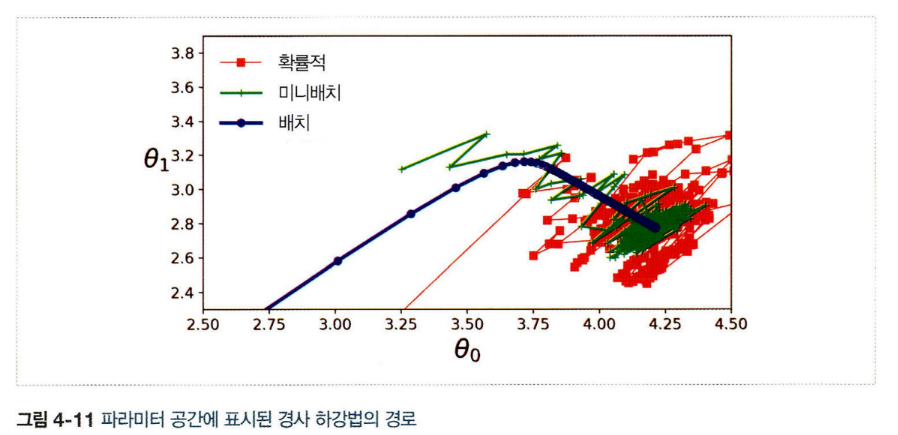

##4.3 다항회귀

In [13]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = poly_features.fit_transform(X)

print(X[0])
print(X_poly[0])

[-1.49788367]
[-1.49788367  2.24365548]


In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.84995095]), array([[1.01579455, 0.52868176]]))

##4.4 학습 곡선

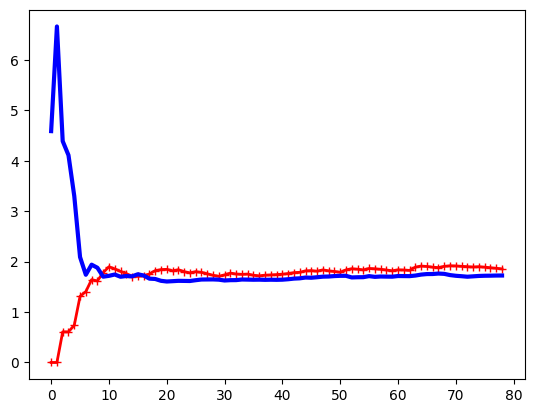

In [18]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)
  train_errors, val_errors = [], []
  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))
  plt.plot(np.sqrt(train_errors), "r-+", linewidth = 2, label = "훈련 세트")
  plt.plot(np.sqrt(val_errors), "b-", linewidth = 3, label = "검증 세트")

lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

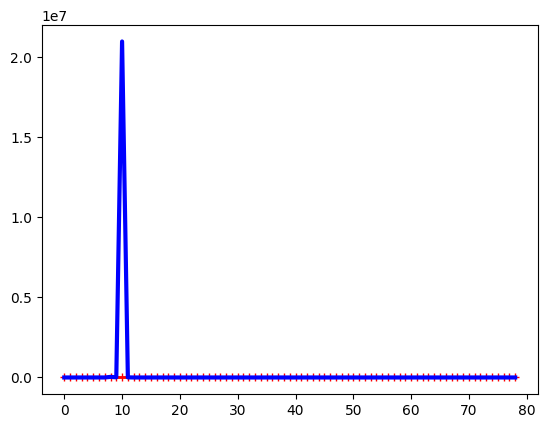

In [20]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree = 10, include_bias = False)),
    ("lin_reg", LinearRegression())
])

plot_learning_curves(polynomial_regression, X, y)